**09 텍스트를 위한 인공 신경망**
====

**09-2 순환 신경망으로 IMDB 리뷰 분류하기**
----

**IMDB 리뷰 데이터셋** (대표적인 순환 신경망 문제)     
유명한 인터넷 영화 데이터베이스인 imdb.com에서 수집한 리뷰를 감사평에 따라 긍정과 부정으로 분류해 놓은 데이터셋     
50,000개의 샘플, 훈련 데이터와 테스트 데이터에 각각 25,000개       

**텍스트 데이터**       
단어를 숫자 데이터로 바꿔야 함 - 데이터에 등장하는 단어마다 고유한 정수를 부여           
ex) He follows the cat. -> He 10, follows 11, the 12, cat 13     

일반적으로 영어 문장은 모두 소문자, 구둣점을 삭제한 다음 공백 기준으로 분리     
-> 분리된 단어 = **토큰 token**      

1개의 샘플은 여러 개의 토큰으로 이루어져 있음, 1개의 토큰이 하나의 타임스텝에 해당     

특정한 용도로 예약되어 있는 정수     
-> 0 : 패딩, 1 : 문장의 시작, 2 : 어휘 사전에 없는 토큰       



In [1]:
# imdb 데이터 적재

from keras.datasets import imdb

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=200)

2025-12-03 12:52:55.865098: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-03 12:52:55.899081: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764733975.946232   42450 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764733975.962213   42450 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-03 12:52:56.014778: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

keras에 이미 정수로 바꾼 데이터가 포함되어 있다       
어휘사전에는 200개 단어만 들어감 -> 어휘사전에 없는 단어는 '2'로 표시      

In [2]:
print(train_input.shape, test_input.shape)

(25000,) (25000,)


리뷰 텍스트는 길이가 제각각     
-> 따라서 고정 크기의 2차원 배열보다 **1차원 배열**에 담아야 메모리를 효율적으로 사용    

In [3]:
print(len(train_input[0]))
print(len(train_input[1]))

218
189


1번째 리뷰는 218개의 토큰     
2번째 리뷰는 189개의 토큰    

In [4]:
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [5]:
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


해결할 문제가 부정(0)과 긍정(1)으로 나누어짐

In [6]:
# 훈련데이터에서 검증데이터(20%) 떼어내기

from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

In [7]:
# 훈련데이터를 리뷰의 길이를 계산해 넘파이 배열에 넣기

import numpy as np

lengths = np.array([len(x) for x in train_input])


# 평균적인 리뷰의 길이, 가장 짧은 리뷰의 길이, 가장 긴 리뷰의 길이 계산    

print(np.mean(lengths), np.median(lengths))

239.00925 178.0


mean, median 함수를 사용하기 위해 넘파이배열에 넣음

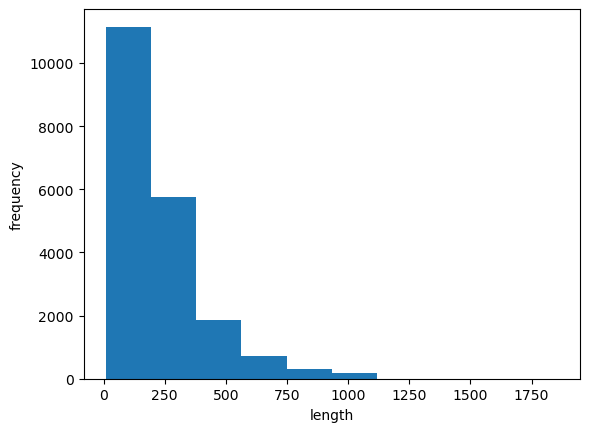

In [8]:
# 리뷰 길이 데이터의 분포 알아보기

import matplotlib.pyplot as plt

plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

대부분의 리뷰가 짧아서 (~300)       
**중간값보다 짧은 100개의 단어만 사용**             

but 100개 보다 짧은 단어의 리뷰도 있음 -> **패딩**이 필요 (보통 **토큰으로는 0** 사용)        

20,000개의 리뷰를 길이가 100이 되도록 **자르거나 0으로 패딩**함


In [9]:
# 훈련 데이터 길이 100으로 맞추기 (단축, 패딩)

from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
print(train_seq.shape)

(20000, 100)


자동으로 **2차원 배열**이 되었음

In [10]:
# 100보다 긴 길이의 샘플

print(train_seq[0])

[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


패딩 값이 0이 없는 것을 보아 100보다 길었을 것

In [11]:
# 샘플이 잘린 부분 확인하기

print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


끝 부분이 동일한 것을 보아 **앞 부분**이 잘렸을 것       

- pad_sequences()     
maxlen 보다 긴 시퀀스의 앞부분을 자른다       
일반적으로 시퀀스의 뒷부분 정보가 유용하리라 기대하기 때문

만약 시퀀스의 뒷부분을 자르고 싶다면      
매개변수 **truncating** 를 기본값 'pre'가 아닌 **post**로 바꾸면 됨


In [12]:
# 100보다 작은 길이의 샘플

print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


In [13]:
# 검증 데이터 100 길이로 만들기

val_seq = pad_sequences(val_input, maxlen=100)

In [14]:
# 순환 신경망 모델 만들기 (SimpleRNN 클래스)

import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,200)))
model.add(keras.layers.SimpleRNN(8))
model.add(keras.layers.Dense(1,activation='sigmoid'))

I0000 00:00:1764733983.292398   42450 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 4GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


**[shape=(100,200)인 이유]**

토큰을 정수로 변환한 이 데이터를 그대로 신경망 모델이 주입할 수 없다    
-> 큰 정수가 큰 활성화 출력을 만듦     

**1. one-hot encoding**    
     
정숫값에 있는 크기 속성을 없애고 각 정수를 고유하게 표현하는 방법    
각 토큰은 n개의 배열에서 n번째 속성에만 1이 들어감     

여기에서는 200개 단어만 사용하도록 지정     
-> one-hot encoding 하면 배열의 길이가 200이 되어야 함



In [15]:
# 훈련데이터 one-hot encoding

train_oh = keras.utils.to_categorical(train_seq)
print(train_oh.shape)

(20000, 100, 200)


In [16]:
# one-hot encoding된 첫 번째 샘플

print(train_oh[0][0][:12])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [17]:
# sum() 함수를 통해 모든 원소의 값의 합이 1이 되는지 확인 
# 인코딩이 잘 됐는지 확인하는 과정

print(np.sum(train_oh[0][0]))

1.0


In [18]:
# 검증 데이터 인코딩

val_oh = keras.utils.to_categorical(val_seq)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

**순환층 출력 크기**      
SimpleRNN에 전달한 샘플의 크기 = (100,200)     
순환층은 마지막 타임스텝의 은닉상태만 출력함      
순환층의 뉴런 개수 = 8 이므로 순환층의 출력 크기 = 8     

**모델 파라미터 개수**       
200 * 8 = 1,600개   
8 * 8 = 64개     
절편 : 8개      
-> **총 1,672개**    




In [20]:
# # 순환 신경망 훈련하기

# model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
# checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras',save_best_only=True)
# early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
# history=model.fit(train_oh, train_target, epochs=100, batch_size=64, validation_data=(val_oh, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

메모리 부족으로 진행 불가    
**train_oh가 용량이 큼**

**2. 단어 임베딩 word embedding**

순환 신경망 모델에서 텍스트를 처리할 때 사용하는 방법     
각 단어를 **고정된 크기의 실수 벡터**로 바꿈    
one-hot encoding보다 훨씬 작은 크기로도 단어 표현 가능     
-> **메모리 절약, 더 많은 단어 사용 가능**         

처음에는 모든 벡터가 랜덤하게 초기화     
훈련을 통해 데이터에서 좋은 단어 임베딩을 학습함     

정수 데이터 -> 실수 벡터로 변경      

**모델 만들 때에 embedding 층을 추가함**

In [21]:
# IMDB data set 준비 (500개 단어 Embedding, 100개 단어까지 단축)

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [22]:
# 순한 신경망 모델 만들기 

model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,)))   # 1.입력의 크기 지정(2차원 배열)
model_emb.add(keras.layers.Embedding(500,16))     # 2.Embedding(어휘 사전의 크기, 벡터 크기)
model_emb.add(keras.layers.SimpleRNN(8))          # 3.SimpleRNN층(뉴런 8개)
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))    #4.Dense층

In [23]:
model_emb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# 순환 신경망 훈련하기

model_emb.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.keras',save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history=model_emb.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8294 - loss: 0.3968 - val_accuracy: 0.7582 - val_loss: 0.5117
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8333 - loss: 0.3891 - val_accuracy: 0.7604 - val_loss: 0.5168
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8355 - loss: 0.3809 - val_accuracy: 0.7512 - val_loss: 0.5775
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8353 - loss: 0.3850 - val_accuracy: 0.7598 - val_loss: 0.5288


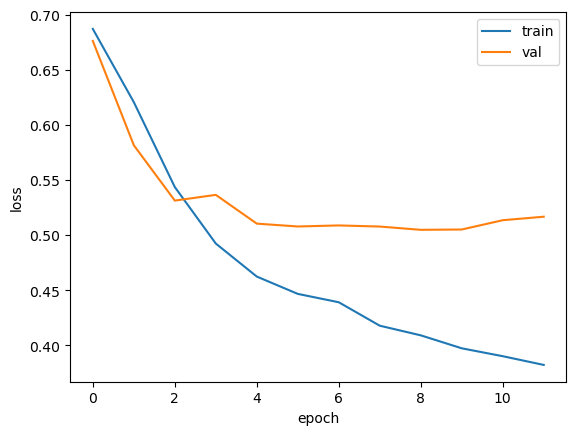

In [25]:
# 훈련 손실, 검증 손실 그래프 출력

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()